# HBR Normal VI benchmark on simulated data

| Method | What it does |
|---|---|
| `mcmc` | NUTS sampling via nutpie. The current default. Exact but slow. |
| `advi` | Mean-field variational inference. Optimises a Gaussian approximation. |
| `pathfinder` | Quasi-Newton variational inference (needs `pymc-extras`). |
| `laplace` | Gaussian centred on the posterior mode, covariance from the Hessian there (needs `pymc-extras`). |

What the ground truth buys us:

1. **Z-score recovery** scored against the true z of every subject
2. **Model Parameter recovery**
3. **Centile calibration** measured against the true centiles

## Imports

In [ ]:
import logging
import time
import warnings

import numpy as np
import pandas as pd

import pcntoolkit.util.output
from pcntoolkit import (
    HBR,
    BsplineBasisFunction,
    NormativeModel,
    NormData,
    make_prior,
    NormalLikelihood
)

logging.getLogger("pymc").setLevel(logging.ERROR)
logging.getLogger("pymc").propagate = False
warnings.simplefilter(action="ignore", category=FutureWarning)
pd.options.mode.chained_assignment = None
pcntoolkit.util.output.Output.set_show_messages(False)



## Generate synthetic data

The data are generated **through the model's own machinery**: the same B-spline
basis, the same softplus mappings, the same `ZeroSumNormal` site offsets.

Everything is simulated on the **standardised scale** the model works in
(`inscaler`/`outscaler` = "standardize"), so recovered and true values are
directly comparable with no unscaling.


In [ ]:
from pcntoolkit.math_functions.basis_function import BsplineBasisFunction
from scipy.stats import norm

SEED = 42
N_SUBJECTS = 1000
N_SITES = 8
N_KNOTS = 5
SPLINE_DEGREE = 3

rng = np.random.default_rng(SEED)

# --- covariates and batch effects ---------------------------------------
age = rng.uniform(10.0, 80.0, size=N_SUBJECTS)
site_idx = rng.integers(0, N_SITES, size=N_SUBJECTS)
sex_idx = rng.integers(0, 2, size=N_SUBJECTS)

# Age enters the model standardised, so simulate on that scale directly.
age_z = (age - age.mean()) / age.std()

# --- the model's own B-spline basis --------------------------------------
# Fitting the basis on age_z means the simulated coefficients are exactly the
# quantities `slope_mu` / `slope_sigma` estimate.
basis = BsplineBasisFunction(basis_column=0, nknots=N_KNOTS, degree=SPLINE_DEGREE)
basis.fit(age_z[:, None])
Phi = np.asarray(basis.transform(age_z[:, None]))
N_BASIS = Phi.shape[1]
print(f"B-spline basis: {N_BASIS} columns")


def softplus(x, a=0.0, b=3.0, c=0.0):
    """The mapping the priors use: log(1 + exp((x - a) / b)) * b + c."""
    return np.log1p(np.exp((x - a) / b)) * b + c


def zsn_std_factor(n: int) -> float:
    """Marginal sd of one component of a `ZeroSumNormal(sigma=1)` with `n` levels.

    The model writes `site_offset = softplus(site_sigma) * ZeroSumNormal(sigma=1)`,
    so `site_sigma` is a scale *factor*, not the offsets' own sd. The zero-sum
    constraint costs one degree of freedom, leaving each component with variance
    `(n - 1) / n` rather than 1 - so the factor is `sqrt((n - 1) / n)`, about
    0.935 at n=8.

    This has to be the *marginal* sd, not the expected `np.std` of a single draw
    (~0.903 at n=8). The two differ by 3.6%, and it is the marginal sd that sets
    the scale: with the offsets fixed, the posterior for the scale factor sits at
    `sqrt(sum(offsets**2) / (n - 1))`, which is the offsets' sd divided by
    `sqrt((n - 1) / n)`. Using the expected-`np.std` version would overstate the
    true `site_sigma` by 3.6% and make every method - MCMC included - look like
    it shrinks the site scale by that much.

    Note the factor cancels between its two uses below: the generator multiplies
    the offsets by it and `truth_for` divides it back out, so the reported truth
    is `site_sigma * SITE_OVERSHOOT` whatever this returns. What it does change
    is the value the *model* estimates, which is what the ratio is scored against.

    Parameters
    ----------
    n : int
        Number of components (sites, sexes, ...).

    Returns
    -------
    float
        `sqrt((n - 1) / n)`, the marginal sd of one zero-sum unit-scale component.
    """
    return float(np.sqrt((n - 1) / n))


SITE_ZSN = zsn_std_factor(N_SITES)


# --- ground truth --------------------------------------------------------
# All values are on the standardised scale, i.e. what the model estimates.
TRUE = {
    "mu_intercept_mu": 0.0,                                  # grand mean
    "slope_mu": rng.normal(0.0, 0.6, size=N_BASIS),          # spline coefs for mu
    # Pre-softplus noise level; softplus(-6, b=3) ~ 0.38, so age explains ~80%
    # of the variance. This sits far out in the tail of sigma's own prior
    # (Normal(1, 1) intercept + Normal(0, 2) coefs through softplus), whose
    # median implies a residual sd ~2.6x the sd of standardised Y - i.e. the
    # prior a priori expects the covariates to explain nothing. That is a
    # property of the standard tutorial prior (notebook 04 uses the same one
    # on real data), not of this value: any dataset where age genuinely
    # predicts the response lands in that tail. It is harmless here because
    # the prior is weak - 800 training points carry ~400x its information, so
    # it shifts the fitted sigma by ~0.5%.
    "intercept_sigma": -6.0,
    "slope_sigma": rng.normal(0.0, 0.8, size=N_BASIS),       # spline coefs for sigma
    "site_sigma": 0.45,      # sd of the site intercepts   <-- key parameter
    "sex_sigma": 0.15,       # sd of the sex intercepts
}

# --- site offsets --------------------------------------------------------
# 1.0 = exactly nominal, 1.3 = 30% wider than site_sigma implies.
SITE_OVERSHOOT = 1.5
# Kept so the random stream downstream is unaffected by fixing the offsets.
_ = rng.normal(0.0, TRUE["site_sigma"], size=N_SITES)

# Site offsets are ZeroSumNormal in the model, so they sum to zero.
#
# SITE_OVERSHOOT adds the deliberate gap
# on top, so the realised spread is exactly site_sigma * SITE_OVERSHOOT once
# the zero-sum factor is divided back out.
site_offsets = norm.ppf(np.arange(1, N_SITES + 1) / (N_SITES + 1))
site_offsets -= site_offsets.mean()
site_offsets *= (TRUE["site_sigma"] * SITE_ZSN * SITE_OVERSHOOT) / site_offsets.std()
TRUE["site_offsets"] = site_offsets

# --- sex offsets ---------------------------------------------------------
SEX_STRENGTH = 1
sex_offsets = np.array([-1.0, 1.0]) * TRUE["sex_sigma"] * SEX_STRENGTH
TRUE["sex_offsets"] = sex_offsets

# --- assemble mu and sigma exactly as the likelihood does -----------------
mu_true = (TRUE["mu_intercept_mu"] + Phi @ TRUE["slope_mu"]
           + site_offsets[site_idx] + sex_offsets[sex_idx])
sigma_true = softplus(TRUE["intercept_sigma"] + Phi @ TRUE["slope_sigma"], 0.0, 3.0)

# --- Normal residuals ----------------------------------------------------
# A Normal likelihood needs no standardising transform: the residual is the
# standard-normal draw itself, so the true z-score is available directly.
z_raw = rng.standard_normal(N_SUBJECTS)
resid = z_raw

# --- simulated data --------------------------------------
y = mu_true + sigma_true * resid

df = pd.DataFrame({
    "age": age,
    "site": [f"site_{i}" for i in site_idx],
    "sex": ["M" if s else "F" for s in sex_idx],
    "synthetic": y,
})

print(f"{N_SUBJECTS} subjects, {N_SITES} sites, no planted outliers")
print(f"true site offsets: {np.round(site_offsets, 3)}")
print(f"true site sigma:   {TRUE['site_sigma']}")
df.head()

### Wrap as NormData and split

In [37]:
features_to_model = ["synthetic"]

norm_data = NormData.from_dataframe(
    "synthetic",
    dataframe=df,
    covariates=["age"],
    batch_effects=["site", "sex"],
    response_vars=features_to_model,
)
train, test = norm_data.train_test_split()

# Keep the ground truth aligned with the test split, so each scored subject can
# be matched back to the values it was generated from.
test_ages = np.asarray(test.X.values)[:, 0]
test_y = np.asarray(test.Y.sel(response_vars="synthetic").values).ravel()
key = {(round(float(a), 9), round(float(v), 9)): i for i, (a, v) in
       enumerate(zip(df["age"], df["synthetic"]))}
test_rows = np.array([key[(round(float(a), 9), round(float(v), 9))]
                      for a, v in zip(test_ages, test_y)])

print(f"train: {train.X.shape[0]}  test: {test.X.shape[0]}")

train: 800  test: 200


### Visualize the data

The design (how many subjects per site, how the sexes are split) and the shape of
the age trend. Because the data are simulated, the black line is the **true**
`mu` for a subject with no site or sex offset - the curve every method is trying
to recover. The vertical spread around it is the sum of the site/sex offsets and
the Gaussian noise.

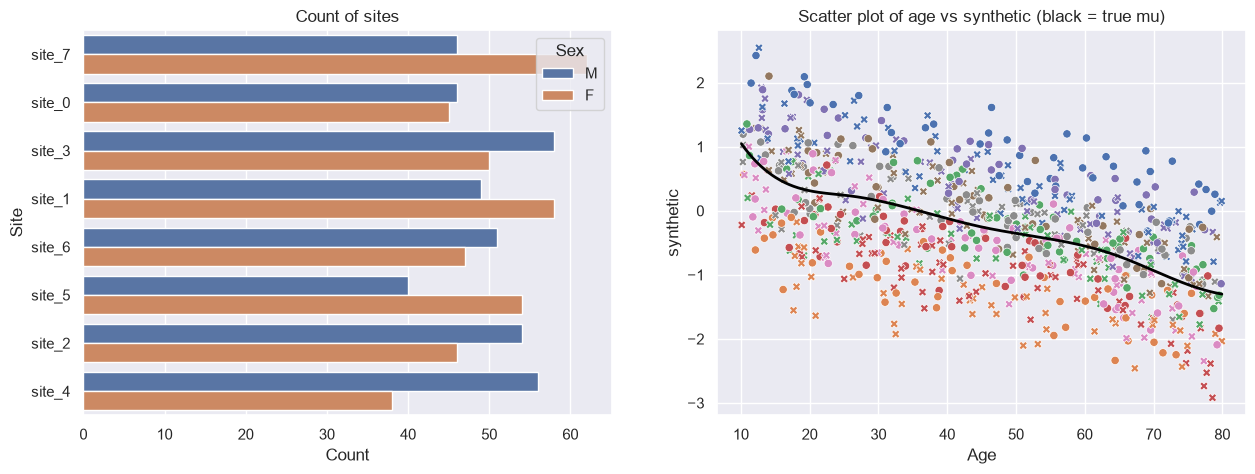

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the data
feature_to_plot = features_to_model[0]
plot_df = train.to_dataframe()
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.countplot(data=plot_df, y=("batch_effects", "site"), hue=("batch_effects", "sex"), ax=ax[0], orient="h")
ax[0].legend(title="Sex")
ax[0].set_title("Count of sites")
ax[0].set_xlabel("Count")
ax[0].set_ylabel("Site")

sns.scatterplot(
    data=plot_df,
    x=("X", "age"),
    y=("Y", feature_to_plot),
    hue=("batch_effects", "site"),
    style=("batch_effects", "sex"),
    ax=ax[1],
)

# The true mu with the site and sex offsets set to zero, i.e. the population
# curve every method is trying to recover. Sorting by age turns the scattered
# simulated points into a line.
order = np.argsort(age)
mu_population = (TRUE["mu_intercept_mu"] + Phi @ TRUE["slope_mu"])[order]
ax[1].plot(age[order], mu_population, color="black", lw=2)

# Drop the per-site/sex legend, which has 16 entries and says nothing here.
ax[1].legend([], [], frameon=False)
ax[1].set_title(f"Scatter plot of age vs {feature_to_plot} (black = true mu)")
ax[1].set_xlabel("Age")
ax[1].set_ylabel(feature_to_plot)

plt.show()


## Model specification

Identical to the Normal benchmark in notebook 15, so any difference in behaviour comes from the
data rather than from the model.

In [ ]:
def make_normal_likelihood() -> NormalLikelihood:
    """The same Normal likelihood used in 15_HBR_Normal_variational_inference_benchmark.ipynb."""
    mu = make_prior(
        linear=True,
        slope=make_prior(dist_name="Normal", dist_params=(0.0, 10.0)),
        intercept=make_prior(
            random=True,
            mu=make_prior(dist_name="Normal", dist_params=(0.0, 1.0)),
            sigma=make_prior(
                dist_name="Normal",
                dist_params=(0.0, 3.0),
                mapping="softplus",
                mapping_params=(0.0, 3.0),
            ),
        ),
        basis_function=BsplineBasisFunction(basis_column=0, nknots=5, degree=3),
    )
    sigma = make_prior(
        linear=True,
        slope=make_prior(dist_name="Normal", dist_params=(0.0, 2.0)),
        intercept=make_prior(dist_name="Normal", dist_params=(1.0, 1.0)),
        basis_function=BsplineBasisFunction(basis_column=0, nknots=5, degree=3),
        mapping="softplus",
        mapping_params=(0.0, 3.0),
    )
    return NormalLikelihood(mu, sigma)


def build_model(inference_method: str) -> NormativeModel:
    """Wrap the Normal HBR in a NormativeModel using the given inference method."""
    reg = HBR(
        name="template",
        cores=16,
        progressbar=False,
        draws=1500,
        tune=500,
        chains=4,
        nuts_sampler="nutpie",
        likelihood=make_normal_likelihood(),
        inference_method=inference_method,
        vi_iterations=30000,
        vi_draws=1000,
    )
    return NormativeModel(
        template_regression_model=reg,
        savemodel=False,
        evaluate_model=False,
        saveresults=False,
        saveplots=False,
        save_dir=f"resources/hbr_normal_synth_bench/{inference_method}",
        inscaler="standardize",
        outscaler="standardize",
    )

## Run the benchmark

In [40]:
timings: dict[str, float] = {}
fits: dict[str, NormativeModel] = {}   # keep every fit for the accuracy checks later

METHODS = ["mcmc", "advi", "pathfinder", "laplace"] # "mcmc", "advi", "pathfinder", "laplace"

for method in METHODS:
    print(f"=== {method} ===")
    try:
        m = build_model(method)
        t = time.time()
        m.fit(train)
        timings[method] = time.time() - t
        fits[method] = m
        print(f"  {method}: {timings[method]:.1f}s\n")
    except ImportError as e:
        print(f"  {method} SKIPPED: {e}\n")
    except Exception as e:
        print(f"  {method} FAILED: {type(e).__name__}: {e}\n")

=== mcmc ===
  mcmc: 148.2s

=== advi ===
  advi: 31.2s

=== pathfinder ===


Pathfinder Results                           
                                             
  No. model parameters     30                
                                             
  Configuration:                             
  num_draws_per_path       1000              
  history size (maxcor)    11                
  max iterations           1000              
  ftol                     1.00e-05          
  gtol                     1.00e-08          
  max line search          1000              
  jitter                   2.0               
  epsilon                  1.00e-12          
  ELBO draws               10                
                                             
  LBFGS Status:                              
  CONVERGED                4                 
  L-BFGS iterations        mean 134 ± std 3  
                                             
  Path Status:                               
  SUCCESS                  4                 
  ELBO argmax              mean 70 ± std 18  
                                             
  Importance Sampling:                       
  Method                   psis              
  Pareto k                 1.92              
                                             
  Timing (seconds):                          
  Compile                  9.46              
  Compute                  24.95             
  Total                    34.41

  pathfinder: 44.1s

=== laplace ===
  laplace: 13.4s



---

# Timing results

In [41]:
ref = timings.get("mcmc")
rows = []
for k, v in sorted(timings.items(), key=lambda kv: kv[1]):
    rows.append({
        "method": k,
        "fit time (s)": round(v, 1),
        "speedup vs mcmc": f"{ref / v:.1f}x" if ref else "n/a",
    })
pd.DataFrame(rows)

,method,fit time (s),speedup vs mcmc
0,laplace,13.4,11.1x
1,advi,31.2,4.8x
2,pathfinder,44.1,3.4x
3,mcmc,148.2,1.0x


---

# Ground-truth results

These are the checks the real-data notebook cannot do.

## 1. Z-scores vs the TRUE z-scores

Because the data were generated from a known Normal model, each subject's true
z-score is available directly: it is the standardised residual `(y - mu) / sigma`,
which is exactly the standard-normal draw the observation was generated from
(asserted in the cell below). So **no method has a privileged status** - MCMC is
scored against the truth like every approximation.

The tail is reported separately (`|true z| > 2`): those subjects are genuine
draws from the model, so a method that keeps them extreme is doing the right
thing.

One column needs care on those rows. The tail subset is selected **on the
truth**, so `sd(z_true)` within it is a conditioned-on-selection quantity rather
than a free spread, and the `sd ratio` there does not mean what it means on the
`all` row. Read the tail `sd ratio` as a description of how far a method pulls
the extremes back, not as a calibration number - the `all` row is the
calibration one.

In [ ]:
from scipy.stats import norm

CENTILES = [0.05, 0.25, 0.5, 0.75, 0.95]
RESPONSE_VARS = [str(r) for r in features_to_model]

# --- the true z-score for every subject ---------------------------------
# For a Normal likelihood the true z is just the standardised residual, which is
# the standard-normal draw the observation was generated from.
z_true_all = (y - mu_true) / sigma_true
assert np.abs(z_true_all - z_raw).max() < 1e-9, "true z must invert the generator"

# --- fitted z-scores, aligned to the test split -------------------------
zs: dict[tuple[str, str], np.ndarray] = {}
for method, m in fits.items():
    td = test.copy()
    m.predict(td)
    for rv in RESPONSE_VARS:
        zs[(method, rv)] = np.asarray(td["Z"].sel(response_vars=rv).values).ravel()

z_true = z_true_all[test_rows]
tail = np.abs(z_true) > 2.0   # genuine tail draws, not contamination

rows = []
for method in fits:
    z = zs[(method, "synthetic")]
    for label, sel in [("all", np.ones_like(tail, dtype=bool)),
                       ("|true z| <= 2", ~tail),
                       ("|true z| > 2", tail)]:
        if sel.sum() < 2:
            continue
        d = np.abs(z[sel] - z_true[sel])
        rows.append({
            "method": method,
            "subjects": label,
            "n": int(sel.sum()),
            "corr with true z": round(float(np.corrcoef(z[sel], z_true[sel])[0, 1]), 4),
            "mean |z - z_true|": round(float(d.mean()), 4),
            "max |z - z_true|": round(float(d.max()), 4),
            "sd ratio": round(float(z[sel].std() / z_true[sel].std()), 4),
        })

ztrue_df = pd.DataFrame(rows)
print("scored against the TRUE z, not against MCMC:")
print(ztrue_df[ztrue_df["subjects"] == "all"]
      .set_index("method")[["corr with true z", "mean |z - z_true|", "sd ratio"]]
      .round(4).to_string())
print()
ztrue_df

### Plot: fitted z against true z

The diagonal is perfect recovery. Subjects with `|true z| > 2` are marked in
red - they are genuine tail draws, and a method that pulls them back towards
zero is shrinking real extremes.

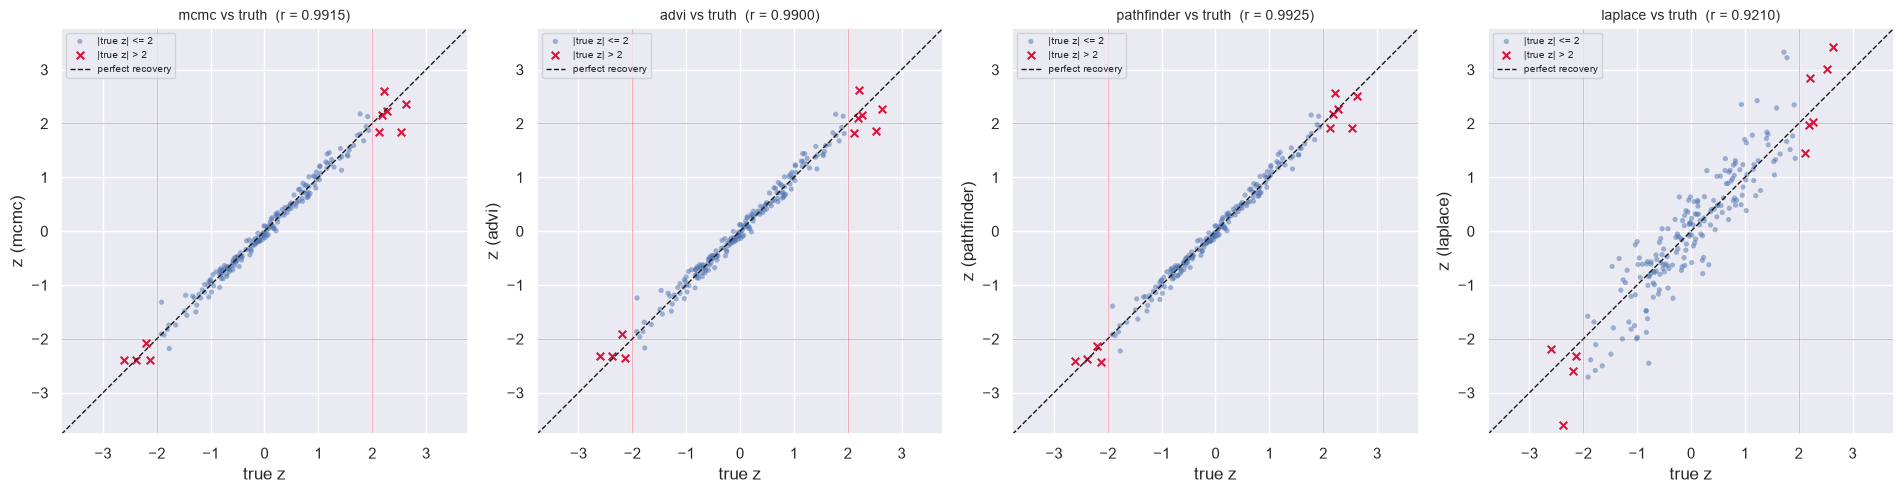

In [43]:
import matplotlib.pyplot as plt

methods_plot = list(fits)
fig, axes = plt.subplots(1, len(methods_plot),
                         figsize=(4.8 * len(methods_plot), 4.8), squeeze=False)
lim = float(np.abs(np.concatenate([z_true] + [zs[(m, "synthetic")] for m in fits])).max()) * 1.05

for ax, method in zip(axes[0], methods_plot):
    z = zs[(method, "synthetic")]
    ax.scatter(z_true[~tail], z[~tail], s=14, alpha=0.5, edgecolor="none",
               label="|true z| <= 2")
    ax.scatter(z_true[tail], z[tail], s=30, color="crimson",
               marker="x", label="|true z| > 2")
    ax.plot([-lim, lim], [-lim, lim], "k--", lw=1, label="perfect recovery")
    for t in (-2, 2):
        ax.axhline(t, color="crimson", lw=0.7, alpha=0.35)
        ax.axvline(t, color="crimson", lw=0.7, alpha=0.35)
    r = np.corrcoef(z, z_true)[0, 1]
    ax.set_title(f"{method} vs truth  (r = {r:.4f})", fontsize=10)
    ax.set_xlabel("true z")
    ax.set_ylabel(f"z ({method})")
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect("equal")
    ax.legend(loc="upper left", fontsize=7)

plt.tight_layout()
plt.show()

### Tail flagging vs the true tail

A subject is flagged when `|z| > 2`. With no contamination, the reference is
the set of subjects whose **true** z exceeds 2 - about 4.6% of a normal sample.
This asks whether a method flags the same subjects the truth does, so it is a
test of tail calibration rather than of outlier detection.

In [44]:
# Tail agreement with the truth. "Correct" here is |true z| > THRESH, so MCMC
# is scored on the same footing as the approximations.
THRESH = 2.0
true_flagged = np.abs(z_true) > THRESH

rows = []
for method in fits:
    z = zs[(method, "synthetic")]
    flagged = np.abs(z) > THRESH
    tp = int((flagged & true_flagged).sum())
    fp = int((flagged & ~true_flagged).sum())
    fn = int((~flagged & true_flagged).sum())
    precision = tp / (tp + fp) if (tp + fp) else float("nan")
    recall = tp / (tp + fn) if (tp + fn) else float("nan")
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else float("nan")
    rows.append({
        "method": method,
        "true tail": int(true_flagged.sum()),
        "flagged": int(flagged.sum()),
        "agree": tp,
        "extra": fp,
        "missed": fn,
        "precision": round(precision, 3),
        "recall": round(recall, 3),
        "F1": round(f1, 3),
    })

print(f"subjects with |true z| > {THRESH}: {int(true_flagged.sum())} of {z_true.size} "
      f"({100 * true_flagged.mean():.1f}%) - the rate a calibrated method should match")
pd.DataFrame(rows).sort_values("F1", ascending=False).reset_index(drop=True)

subjects with |true z| > 2.0: 10 of 200 (5.0%) - the rate a calibrated method should match


,method,true tail,flagged,agree,extra,missed,precision,recall,F1
0,mcmc,10,11,8,3,2,0.727,0.8,0.762
1,pathfinder,10,11,8,3,2,0.727,0.8,0.762
2,advi,10,10,7,3,3,0.700,0.7,0.700
3,laplace,10,21,8,13,2,0.381,0.8,0.516


## 2. Parameter recovery: recovered / true

Every parameter is reported as a **recovery ratio** - the recovered value
divided by the truth - so **1.0 is perfect**. Nothing is compared to MCMC:
MCMC is scored against the truth on the same footing as the approximations.

Parameters are listed by their **raw posterior names**.

Two of notebook 15's parameters are missing here: `sex_offset_intercept_mu` and
`sex_sigma_intercept_mu`. Sex has two levels, so its zero-sum offsets are a
single number and its scale rests on one contrast - those panels were reporting
draw noise rather than inference quality. Site, with eight levels, exercises
the same machinery properly.

Every summary is computed **per draw and then averaged**, never the other way
round. `softplus` and `rms` are nonlinear, so the order changes the answer, and
summarising each draw is what leaves a spread to report a posterior sd from.

Vector parameters are compared through a scalar summary, named in each panel:

- `rms` - the root-mean-square of the offsets, i.e. their spread.
- `curve rms` / `curve mean` - `slope_mu` and `slope_sigma` are spline
  coefficients on knots fitted to the *training* split, while the generator's
  knots come from all subjects. The coefficients are therefore not comparable
  one to one, but the curve they generate on a shared age grid is, so that is
  what gets scored.

### What has no ground truth, and why

Two parameters get a blank panel. This is not a failure of any method - the
data simply do not identify them, so there is no honest number to score.

- **`mu_intercept_mu` and `intercept_sigma`.** The B-spline design matrix is a
  *partition of unity*: its spline columns sum to exactly 1 in every row (the
  cell below asserts this). So adding a constant to an intercept and taking the
  same constant off every spline coefficient leaves `mu` and `sigma`
  bit-identical. Each intercept is exactly aliased with its spline
  coefficients, and its posterior reflects the prior rather than the data.
  What *is* identified is the curve - which is exactly what `slope_mu` and
  `slope_sigma` are scored on.
`normalized_site_offset_intercept_mu` used to be listed here too. It is not
unidentified: `ZeroSumNormal(sigma=1)` is a fixed-scale prior rather than a free
hierarchical scale, so it pins the normalized vector and the split of
`site_offset = softplus(site_sigma) * normalized_site_offset` between its two
factors is well determined. It is scored below, against
`rms(site_offsets) / softplus(site_sigma_true)`.

### Getting the scaling right

This means following what `NormativeModel` does to the data:

- **The outscaler centres and scales Y.** Offsets and between-group scales are
  differences, so the mean cancels and dividing by `Y_SD` is enough.
- **`site_sigma` is a scale factor, not an sd.** The offsets are
  `softplus(site_sigma)` times a `ZeroSumNormal(sigma=1)`, and the zero-sum
  constraint costs one degree of freedom: eight such draws have a realised sd
  of about 0.90, not 1.0. The truth is therefore the offsets' sd divided by
  that factor, which the cell below estimates by simulation. Without the
  correction every method - MCMC included - looks like it inflates the site
  scale by ~11%.
- **`delta` is stored pre-softplus**, so the mapping is applied to every draw
  before it is compared against the natural-scale truth.


In [ ]:
# --- exactly what the model does to the data -----------------------------
# NormativeModel.preprocess -> scale_forward fits a StandardScaler per response
# variable on the TRAINING split, using np.std (ddof=0).
y_train = np.asarray(train.Y.sel(response_vars="synthetic").values).ravel()
Y_MEAN, Y_SD = float(y_train.mean()), float(y_train.std())

# The covariate scaler is fitted on the training split as well, so the model's
# spline sits on knots derived from the training ages - not from all of them.
x_train = np.asarray(train.X.sel(covariates="age").values)
X_MEAN, X_SD = float(x_train.mean()), float(x_train.std())

print(f"outscaler: mean {Y_MEAN:.4f}  sd {Y_SD:.4f}")
print(f"inscaler:  mean {X_MEAN:.4f}  sd {X_SD:.4f}\n")


def flat(samples) -> np.ndarray:
    return np.asarray(samples).reshape(-1)


def rms(a) -> float:
    return float(np.sqrt(np.mean(np.asarray(a) ** 2)))

# The model's own basis: fitted on training ages scaled by the inscaler, and
# BsplineBasisFunction._transform prepends the raw column, so the design matrix
# is [x, spline...]. Rebuilding it the same way keeps the curves comparable.
model_basis = BsplineBasisFunction(basis_column=0, nknots=N_KNOTS, degree=SPLINE_DEGREE)
model_basis.fit(((x_train - X_MEAN) / X_SD)[:, None])

# The spline columns are a partition of unity, so a constant lives in their
# span and neither intercept is identified. This is why `mu_intercept_mu` and
# `intercept_sigma` get no ground truth below.
assert np.allclose(Phi[:, 1:].sum(axis=1), 1.0)

age_grid = np.linspace(age.min(), age.max(), 100)
Phi_model = np.asarray(model_basis.transform(((age_grid - X_MEAN) / X_SD)[:, None]))
Phi_truth = np.asarray(basis.transform(((age_grid - age.mean()) / age.std())[:, None]))

# The true mu curve, expressed on the standardised Y scale the model works on.
true_mu_curve = (TRUE["mu_intercept_mu"] + Phi_truth @ TRUE["slope_mu"] - Y_MEAN) / Y_SD
true_sigma_curve = softplus(TRUE["intercept_sigma"] + Phi_truth @ TRUE["slope_sigma"],
                            0.0, 3.0) / Y_SD


def truth_for(param: str) -> tuple[float, str]:
    """Ground truth for one posterior variable, on the model's own scale.

    Parameters
    ----------
    param : str
        Posterior variable name, exactly as it appears in `idata.posterior`.

    Returns
    -------
    tuple[float, str]
        The true value, and a short note on how vectors were reduced to it.
        `nan` marks a parameter that carries no independent ground truth.
    """
    site = TRUE["site_offsets"] / Y_SD
    return {
        # The B-spline columns are a partition of unity: they sum to 1 in every
        # row (asserted below). So adding c to an intercept and subtracting c
        # from every spline coefficient leaves mu and sigma bit-identical - the
        # intercepts are exactly aliased with the spline coefficients and carry
        # no truth of their own. What IS identified is the curve, which is what
        # slope_mu and slope_sigma are scored on.
        "mu_intercept_mu": (float("nan"), "not identified"),
        "intercept_sigma": (float("nan"), "not identified"),
        "site_offset_intercept_mu": (rms(site), "rms"),
        # site_sigma is the SCALE FACTOR multiplying a ZeroSumNormal, not the
        # offsets' realised sd - hence the SITE_ZSN correction.
        "site_sigma_intercept_mu": (float(np.std(site)) / SITE_ZSN, "softplus"),
        # site_offset = softplus(site_sigma) * normalized_site_offset. The split
        # IS identified: ZeroSumNormal(sigma=1) is a fixed-scale prior, not a
        # free hierarchical scale, so it pins the normalized vector. Its truth
        # is therefore the offsets' rms divided by the true scale factor - and
        # since that scale factor is itself std(site) / SITE_ZSN, the ratio
        # comes out at SITE_ZSN, the marginal sd of a unit zero-sum component.
        "normalized_site_offset_intercept_mu": (
            rms(site) / (float(np.std(site)) / SITE_ZSN),
            "rms",
        ),
        # The model's spline knots come from the training split and the
        # generator's from all subjects, so the coefficients are not comparable
        # one to one. The curve they generate is, so score that instead.
        "slope_mu": (rms(true_mu_curve - true_mu_curve.mean()), "curve rms"),
        "slope_sigma": (float(true_sigma_curve.mean()), "curve mean"),
    }[param]


# Parameters the priors store pre-softplus: the natural-scale value is what the
# model actually uses, so the mapping has to be applied before comparing.
SOFTPLUS_PARAMS = {
    "site_sigma_intercept_mu": (0.0, 3.0, 0.0),
}


def draws_of(param: str, post) -> np.ndarray:
    """The summary in `truth_for` evaluated separately on every posterior draw.

    Every parameter is reduced the same way: transform each draw, then reduce.
    Doing it in that order matters because the reductions are nonlinear
    (`softplus`, `rms`), so summarising the posterior mean instead would give a
    different number - and would leave no spread to report a posterior sd from.

    Parameters
    ----------
    param : str
        Posterior variable name, exactly as it appears in `idata.posterior`.
    post : xarray.Dataset
        The `idata.posterior` group of one fitted regression model.

    Returns
    -------
    np.ndarray
        One summary value per draw, on the same scale as `truth_for`.
    """
    arr = np.asarray(post[param].values)

    if param == "slope_mu":
        # The mu curve each draw implies, centred, then reduced to its spread.
        curves = np.einsum("gc,dc->dg", Phi_model, arr.reshape(-1, arr.shape[-1]))
        return np.sqrt(((curves - curves.mean(axis=1, keepdims=True)) ** 2).mean(axis=1))

    if param == "slope_sigma":
        # intercept_sigma is not identified on its own, but the SUM
        # intercept_sigma + Phi @ slope_sigma is - that sum is the sigma curve,
        # which is what gets scored. Pair each draw with its own intercept.
        ic = flat(post["intercept_sigma"].values)
        sl = arr.reshape(-1, arr.shape[-1])
        assert ic.shape[0] == sl.shape[0], "intercept and slope draws must align"
        curves = np.einsum("gc,dc->dg", Phi_model, sl) + ic[:, None]
        return softplus(curves, 0.0, 3.0).mean(axis=1)

    if param in SOFTPLUS_PARAMS:
        return softplus(flat(arr), *SOFTPLUS_PARAMS[param])

    if arr.ndim > 2:                       # a vector of offsets, one rms per draw
        v = arr.reshape(-1, arr.shape[-1])
        return np.sqrt((v ** 2).mean(axis=1))

    return flat(arr)


# Notebook 15's parameter list minus the two sex entries. Sex has only two
# levels, so its zero-sum offsets are a single number and its scale is not
# meaningfully estimable from one contrast - the panels measured draw noise
# rather than inference quality. The site effect (8 levels) carries the same
# information and is what the between-group checks below use.
PARAMS = sorted([
    "intercept_sigma",
    "mu_intercept_mu",
    "normalized_site_offset_intercept_mu",
    "site_offset_intercept_mu",
    "site_sigma_intercept_mu",
    "slope_mu",
    "slope_sigma",
])

rows = []
for method in fits:
    post = fits[method]["synthetic"].idata.posterior
    for param in PARAMS:
        if param not in post:
            continue
        truth, how = truth_for(param)
        # Summarise every draw, then take the mean and sd of those summaries.
        # The sd is therefore the spread of the quantity actually being scored,
        # so `|bias| / post sd` compares like with like even for the vector
        # parameters.
        d = draws_of(param, post)
        rec = float(d.mean())
        post_sd = float(d.std())
        ok = np.isfinite(truth)
        rows.append({
            "method": method,
            "parameter": param,
            "summary": how,
            "true": round(truth, 4),
            "recovered": round(rec, 4),
            "recovered / true": round(rec / truth, 3) if ok and truth else np.nan,
            "abs error": round(abs(rec - truth), 4) if ok else np.nan,
            "|bias| / post sd": round(abs(rec - truth) / post_sd, 2)
            if ok and post_sd else np.nan,
        })

recovery_df = pd.DataFrame(rows)

print("recovery ratio (1.0 = perfect; <1 shrinks, >1 inflates):")
print(recovery_df.pivot(index="parameter", columns="method",
                        values="recovered / true").round(3).to_string())

# mu_intercept_mu is a location on a shifted scale, so its ratio is not
# meaningful - the bias in posterior-sd units is what to read there.
print("\nbias in posterior-sd units (how far off relative to the claimed precision):")
print(recovery_df.pivot(index="parameter", columns="method",
                        values="|bias| / post sd").round(2).to_string())
print()
recovery_df.sort_values(["parameter", "method"]).reset_index(drop=True)

### Recovery ratio per parameter

One panel per parameter, one bar per method, with a dashed line at 1.0. Bars
near the line recover the truth; short bars shrink it, tall bars inflate it.

The panels use notebook 15's raw parameter names, so the two figures can be
read side by side - minus the two sex parameters, and with the three
unidentified parameters shown as blank panels rather than as bars against a
truth that does not exist.

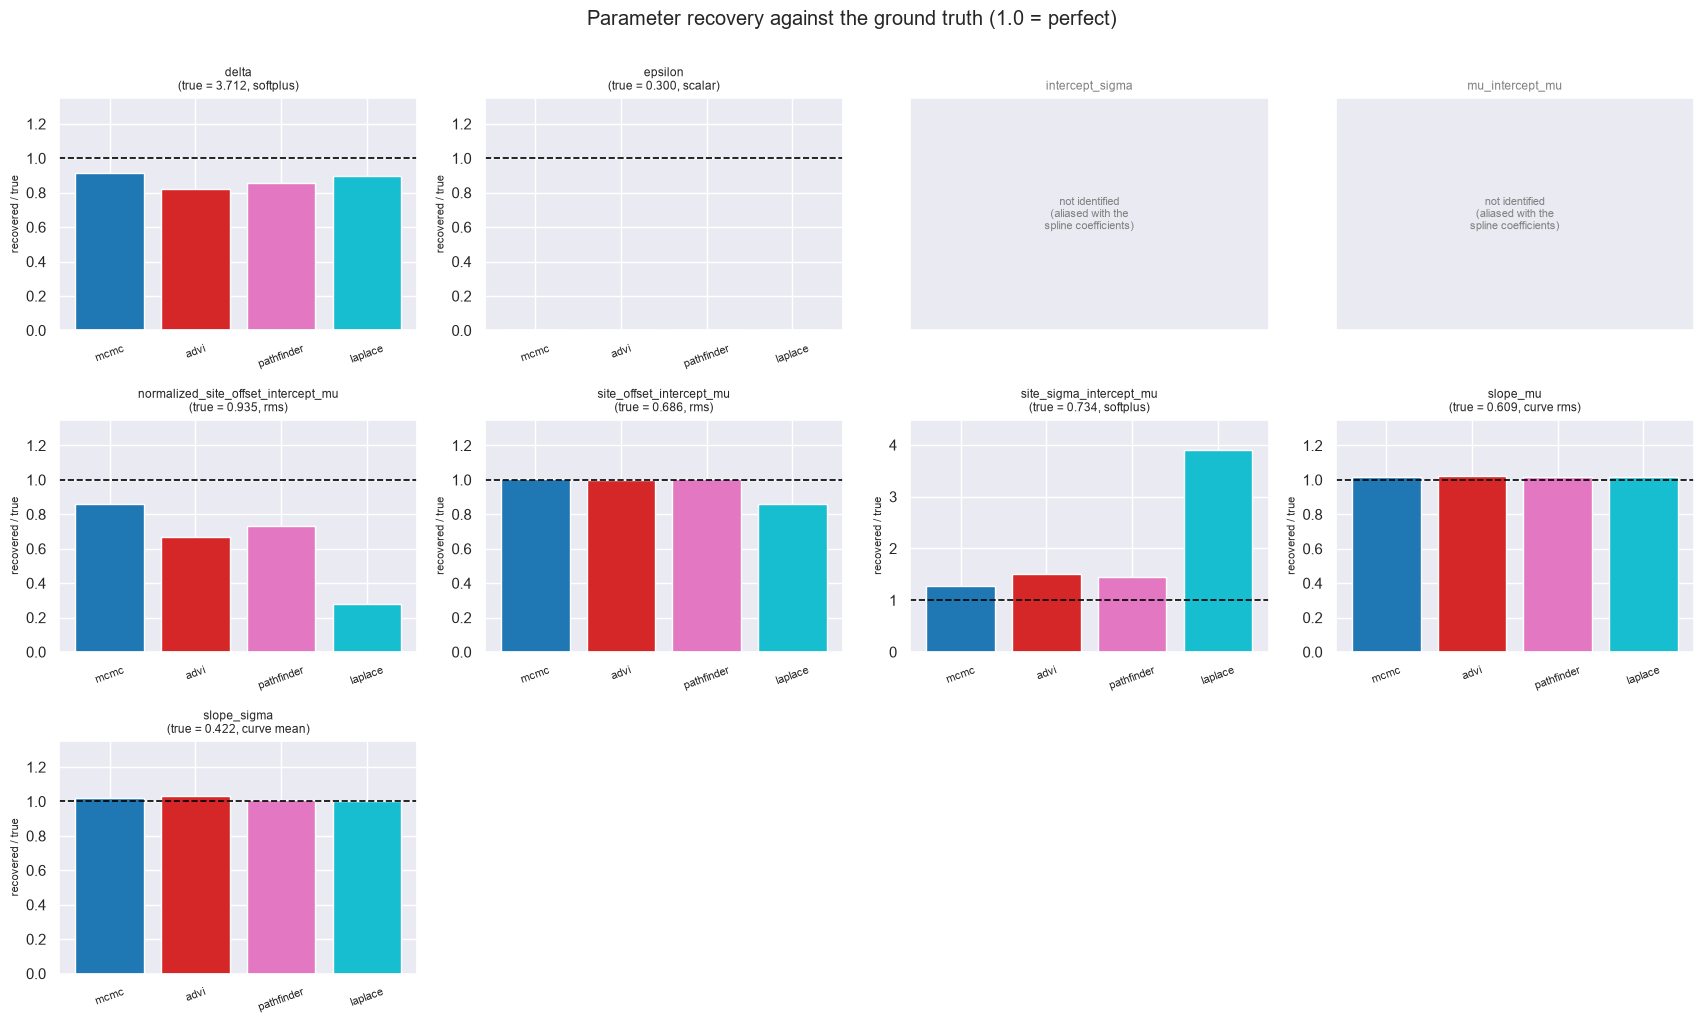

In [46]:
import matplotlib.pyplot as plt

# Same parameter names, in the same order, as notebook 04's sd_ratio table.
params = [p for p in PARAMS if p in set(recovery_df["parameter"])]
methods = list(recovery_df["method"].unique())
colors = dict(zip(methods, plt.cm.tab10(np.linspace(0, 0.9, len(methods)))))

ncols = 4
nrows = int(np.ceil(len(params) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.3 * ncols, 3.4 * nrows), squeeze=False)

for k, param in enumerate(params):
    ax = axes[k // ncols][k % ncols]
    sub = recovery_df[recovery_df["parameter"] == param].set_index("method")
    truth, how = sub["true"].iloc[0], sub["summary"].iloc[0]

    # Parameters that carry no ground truth get an empty panel, so the grid
    # still lines up with notebook 04's parameter list.
    if not np.isfinite(truth):
        note = "not identified\n(aliased with the\nspline coefficients)"
        ax.text(0.5, 0.5, note, ha="center", va="center", fontsize=8,
                color="grey", transform=ax.transAxes)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(param, fontsize=8.5, color="grey")
        continue

    vals = [sub.loc[m, "recovered / true"] if m in sub.index else np.nan
            for m in methods]
    ax.bar(range(len(methods)), vals, color=[colors[m] for m in methods])
    ax.set_xticks(range(len(methods)))
    ax.set_xticklabels(methods, rotation=20, fontsize=8)
    ax.set_ylabel("recovered / true", fontsize=8)
    ax.axhline(1.0, color="black", ls="--", lw=1.2)
    # Keep the 1.0 line visible even when a method is far off.
    ax.set_ylim(0, max(1.35, float(np.nanmax(vals)) * 1.15))
    ax.set_title(f"{param}\n(true = {truth:.3f}, {how})", fontsize=8.5)

for k in range(len(params), nrows * ncols):
    axes[k // ncols][k % ncols].axis("off")

fig.suptitle("Parameter recovery against the ground truth (1.0 = perfect)", y=1.001)
plt.tight_layout()
plt.show()

### Posterior width vs MCMC - the same table as notebook 15

The literal notebook 15 comparison, same formula, same parameters:

- **`sd_ratio = sd(method) / sd(mcmc)`** - below 1 means the method's posterior
  is narrower than MCMC's, i.e. it claims more precision than MCMC does.
- **`mean_shift`** - the gap between the two posterior means, in units of
  MCMC's sd.

Included so the two notebooks can be read side by side, figure for figure. Note
what it cannot do: MCMC is the yardstick here, so MCMC scores exactly 1.0 on
every parameter by construction and its own errors are invisible. The recovery
figure above is the one that catches those - compare
`site_sigma_intercept_mu` in the two figures.

Two differences from the figure above are worth keeping in mind when reading
them side by side. This table works on the **raw** posterior with no rescaling
and no `softplus`, because a ratio of two sds of the same variable is
scale-free - so `site_sigma_intercept_mu` and `delta` are on their pre-softplus
scale here and on their natural scale above. And the unidentified parameters
still get a bar here: a posterior width is well defined even when the location
it surrounds is not.

A third difference matters for the **vector** parameters (`slope_mu`,
`site_offset_intercept_mu`, `normalized_site_offset_intercept_mu`). Notebook 15
takes `np.std` over the whole posterior array, which pools the spread *across
components* - a property of the location - in with the spread across draws. For
those rows the ratio is driven mostly by how far apart the components sit, and
it only reduces to a posterior width if the two methods have the same means. The
recovery figure above does not have this problem: `draws_of` reduces each draw to
a scalar first, so the sd it reports is the spread of the quantity actually being
scored. Where the two figures disagree on a vector parameter, trust the one
above.

In [47]:
# Posterior width against MCMC, computed exactly as notebook 04 does it.
# One response variable here, so there is nothing to average over.
others = [k for k in fits if k != "mcmc"]
ref_post = fits["mcmc"]["synthetic"].idata.posterior

rows = []
for method in others:
    post = fits[method]["synthetic"].idata.posterior
    for v in PARAMS:
        if v not in post or v not in ref_post:
            continue
        a = np.asarray(post[v].values)
        b = np.asarray(ref_post[v].values)
        if a.size == 0 or b.size == 0 or b.std() == 0:
            continue
        rows.append({
            "method": method,
            "parameter": v,
            "sd_ratio": round(float(a.std() / b.std()), 3),
            "mean_shift (sd)": round(float(abs(a.mean() - b.mean()) / b.std()), 2),
        })

width_df = pd.DataFrame(rows)

print("sd_ratio vs MCMC (1.0 = matches MCMC; <1 = narrower than MCMC):")
print(width_df.pivot(index="parameter", columns="method",
                     values="sd_ratio").round(3).to_string())
print("\nmean_shift in MCMC-sd units (how far the centre moved from MCMC's):")
print(width_df.pivot(index="parameter", columns="method",
                     values="mean_shift (sd)").round(2).to_string())
print()
width_df.sort_values(["method", "sd_ratio"]).reset_index(drop=True)

sd_ratio vs MCMC (1.0 = matches MCMC; <1 = narrower than MCMC):
method                                advi  laplace  pathfinder
parameter                                                      
delta                                0.991    0.000       0.362
epsilon                              0.659    0.919       0.715
intercept_sigma                      0.118    0.908       0.244
mu_intercept_mu                      0.018    0.919       0.313
normalized_site_offset_intercept_mu  0.746    0.345       0.853
site_offset_intercept_mu             0.997    0.883       1.004
site_sigma_intercept_mu              0.071    2.109       0.772
slope_mu                             0.136    0.264       0.137
slope_sigma                          0.818    0.866       0.517

mean_shift in MCMC-sd units (how far the centre moved from MCMC's):
method                               advi  laplace  pathfinder
parameter                                                     
delta                                

,method,parameter,sd_ratio,mean_shift (sd)
0,advi,mu_intercept_mu,0.018,0.04
1,advi,site_sigma_intercept_mu,0.071,0.67
2,advi,intercept_sigma,0.118,1.25
3,advi,slope_mu,0.136,0.02
4,advi,epsilon,0.659,0.07
5,advi,normalized_site_offset_intercept_mu,0.746,0.00
6,advi,slope_sigma,0.818,0.44
7,advi,delta,0.991,0.63
8,advi,site_offset_intercept_mu,0.997,0.00
9,laplace,delta,0.000,0.07


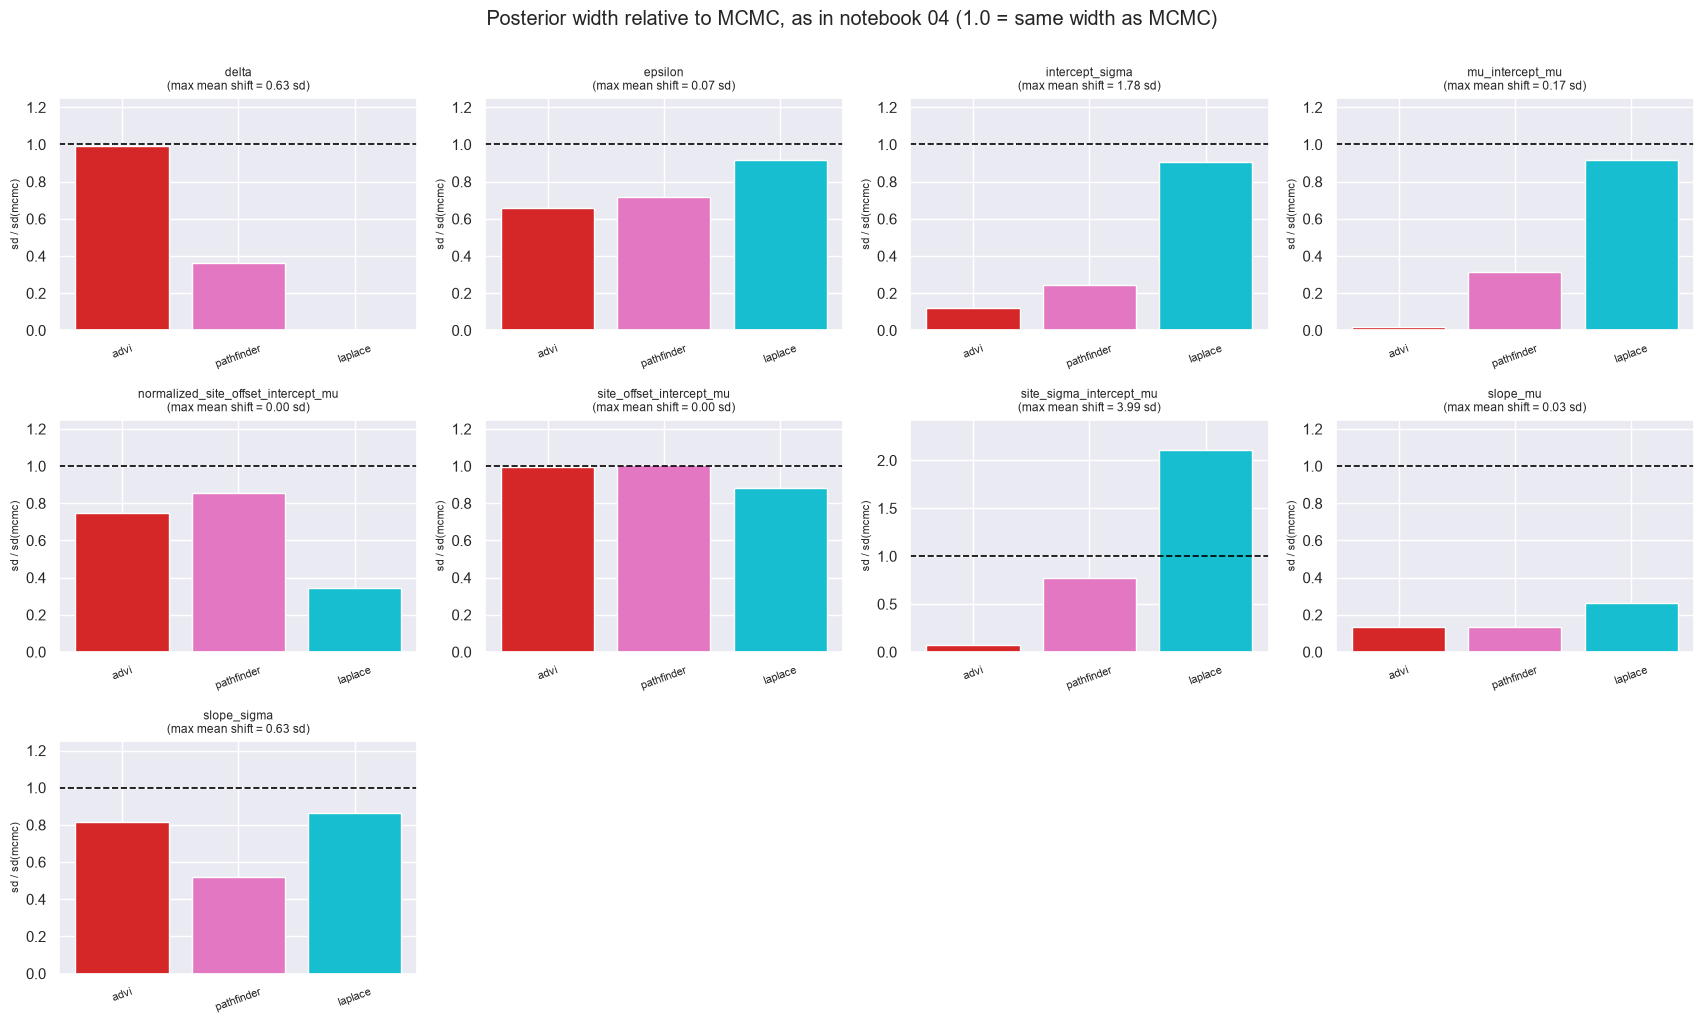

In [48]:
import matplotlib.pyplot as plt

# Same panel grid as the recovery figure; MCMC is the reference, so it has no
# bar of its own here.
params = [p for p in PARAMS if p in set(width_df["parameter"])]
w_methods = list(width_df["method"].unique())
# Reuse the recovery figure's palette so a method keeps its colour throughout.
colors = dict(zip(list(fits), plt.cm.tab10(np.linspace(0, 0.9, len(fits)))))

ncols = 4
nrows = int(np.ceil(len(params) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.3 * ncols, 3.4 * nrows), squeeze=False)

for k, param in enumerate(params):
    ax = axes[k // ncols][k % ncols]
    sub = width_df[width_df["parameter"] == param].set_index("method")
    vals = [sub.loc[m, "sd_ratio"] if m in sub.index else np.nan for m in w_methods]
    ax.bar(range(len(w_methods)), vals, color=[colors[m] for m in w_methods])
    ax.axhline(1.0, color="black", ls="--", lw=1.2)
    ax.set_xticks(range(len(w_methods)))
    ax.set_xticklabels(w_methods, rotation=20, fontsize=8)
    ax.set_ylabel("sd / sd(mcmc)", fontsize=8)
    # Keep the 1.0 reference line visible even when a method is far off.
    ax.set_ylim(0, max(1.25, float(np.nanmax(vals)) * 1.15))
    ax.set_title(f"{param}\n(max mean shift = {sub['mean_shift (sd)'].max():.2f} sd)",
                 fontsize=8.5)

for k in range(len(params), nrows * ncols):
    axes[k // ncols][k % ncols].axis("off")

fig.suptitle("Posterior width relative to MCMC, as in notebook 04 "
             "(1.0 = same width as MCMC)", y=1.001)
plt.tight_layout()
plt.show()

## 3. Centile calibration vs the truth

For normative modelling the centiles *are* the product. A well-calibrated model
puts 5% of test subjects below its 5th centile, 25% below its 25th, and so on.
Every subject counts here, since all of them were drawn from the model.

In [49]:
# Centile calibration against the truth: what fraction of test subjects fall
# below each predicted centile? Perfect calibration matches the nominal value.
rows = []
for method, m in fits.items():
    td = test.copy()
    m.compute_centiles(td, centiles=CENTILES)
    c = np.asarray(td["centiles"].sel(response_vars="synthetic").values)
    row = {"method": method}
    for i, cent in enumerate(CENTILES):
        below = test_y < c[i]
        row[f"{int(cent * 100)}%"] = round(100 * float(below.mean()), 1)
    rows.append(row)

cov_df = pd.DataFrame(rows)
nominal = {f"{int(c * 100)}%": 100 * c for c in CENTILES}
print("nominal:", nominal)
print("(entries are the empirical % below each centile; closer to nominal is better)")
cov_df

nominal: {'5%': 5.0, '25%': 25.0, '50%': 50.0, '75%': 75.0, '95%': 95.0}
(entries are the empirical % below each centile; closer to nominal is better)


,method,5%,25%,50%,75%,95%
0,mcmc,5.0,25.5,52.0,73.5,93.5
1,advi,5.0,24.5,52.5,73.5,93.5
2,pathfinder,5.0,25.5,52.0,73.0,93.5
3,laplace,6.0,24.5,50.0,74.0,92.5


## 4. Centile curves vs the true curves

The equivalent of notebook 15's centile overlay, but the reference is the
**true** curve rather than MCMC's estimate. Because the data were generated
from a known Normal model, the true centile at a given age is available in
closed form: take the standard-normal quantile for that centile, scale it by
the true `sigma(age)` and shift by the true `mu(age)`.

Solid = truth, dashed = the method. A method that tracks the solid line is
right; MCMC has no privileged status here.


In [ ]:
from scipy.stats import norm

# A fixed site and sex, so the curves are comparable across methods.
CURVE_SITE = 0
CURVE_SEX = 0

# --- true centile curves -------------------------------------------------
grid_age = np.linspace(age.min(), age.max(), 200)
# The truth was built on the generator's own basis, so evaluate it there; the
# fitted centiles come back from compute_centiles already in raw Y units.
Phi_grid = np.asarray(basis.transform(((grid_age - age.mean()) / age.std())[:, None]))

mu_grid = (TRUE["mu_intercept_mu"] + Phi_grid @ TRUE["slope_mu"]
           + TRUE["site_offsets"][CURVE_SITE] + TRUE["sex_offsets"][CURVE_SEX])
sigma_grid = softplus(TRUE["intercept_sigma"] + Phi_grid @ TRUE["slope_sigma"], 0.0, 3.0)

# A Normal likelihood needs no standardising transform, so the true centile is
# the standard-normal quantile scaled by sigma and shifted by mu.
true_curves = np.empty((len(CENTILES), grid_age.size))
for i, cent in enumerate(CENTILES):
    true_curves[i] = mu_grid + sigma_grid * norm.ppf(cent)

# --- fitted centile curves on the same grid ------------------------------
curve_df = pd.DataFrame({
    "age": grid_age,
    "site": f"site_{CURVE_SITE}",
    "sex": "M" if CURVE_SEX else "F",
    "synthetic": 1e-6,
})


def make_curve_grid() -> NormData:
    """Fresh NormData for the curve grid (compute_centiles mutates its input)."""
    return NormData.from_dataframe(
        "curve_grid",
        dataframe=curve_df.copy(),
        covariates=["age"],
        batch_effects=["site", "sex"],
        response_vars=["synthetic"],
    )


fitted_curves: dict[str, np.ndarray] = {}
for method, m in fits.items():
    gd = make_curve_grid()
    m.compute_centiles(gd, centiles=CENTILES)
    fitted_curves[method] = np.asarray(gd["centiles"].sel(response_vars="synthetic").values)

# --- plot ----------------------------------------------------------------
methods_plot = list(fits)
fig, axes = plt.subplots(1, len(methods_plot),
                         figsize=(5.6 * len(methods_plot), 5.0), squeeze=False)
colors = plt.cm.viridis(np.linspace(0, 0.9, len(CENTILES)))

# Only the subjects at this site/sex are on these curves.
mask = (df["site"] == f"site_{CURVE_SITE}") & (df["sex"] == ("M" if CURVE_SEX else "F"))

for ax, method in zip(axes[0], methods_plot):
    for i, cent in enumerate(CENTILES):
        ax.plot(grid_age, true_curves[i], color=colors[i], lw=2,
                label=f"true {int(cent * 100)}%")
        ax.plot(grid_age, fitted_curves[method][i], color=colors[i], lw=1.6, ls="--",
                label=f"{method} {int(cent * 100)}%")
    ax.scatter(df.loc[mask, "age"], df.loc[mask, "synthetic"],
               s=8, color="black", alpha=0.25, zorder=0, label="subjects")
    ax.set_title(f"{method}: true (solid) vs fitted (dashed)", fontsize=10)
    ax.set_xlabel("age")
    ax.set_ylabel("synthetic")
    ax.legend(fontsize=6, ncol=2)

plt.tight_layout()
plt.show()

### Centile error against the truth

The same curves as a single number per method: the absolute gap between the
fitted and the true centile, as a percentage of the response variable's
standard deviation. Lower is better, and unlike notebook 15 this is an error
against the truth rather than a disagreement with MCMC.

In [51]:
y_sd_synth = float(np.std(df["synthetic"]))

rows = []
for method, curves in fitted_curves.items():
    d = np.abs(curves - true_curves)
    for i, cent in enumerate(CENTILES):
        rows.append({
            "method": method,
            "centile": f"{int(cent * 100)}%",
            "mean err (% Y sd)": round(100 * float(d[i].mean()) / y_sd_synth, 2),
            "max err (% Y sd)": round(100 * float(d[i].max()) / y_sd_synth, 2),
        })

curve_err = pd.DataFrame(rows)
print("mean absolute centile error vs the truth, over all centiles:")
print(curve_err.groupby("method")[["mean err (% Y sd)", "max err (% Y sd)"]]
      .mean().round(2).sort_values("mean err (% Y sd)").to_string())
print()
curve_err.pivot(index="centile", columns="method", values="mean err (% Y sd)").round(2)

mean absolute centile error vs the truth, over all centiles:
            mean err (% Y sd)  max err (% Y sd)
method                                         
pathfinder               4.62             10.20
mcmc                     4.80             11.98
advi                     4.81             13.54
laplace                 20.23             28.07



method,advi,laplace,mcmc,pathfinder
centile,,,,
25%,4.31,20.62,4.22,3.98
5%,6.61,19.41,6.02,5.46
50%,3.65,20.90,3.73,3.82
75%,4.10,20.52,4.34,4.40
95%,5.39,19.69,5.67,5.45
